# 02 — Data Preprocessing & Feature Engineering

**Input:** `datasets/marketing_sample_for_ebay_com-ebay_com_product__20210101_20210331__30k_data.csv`  
**Output:** `datasets/ebay_processed.parquet`

## Goal

Transform the raw Kaggle dump into a clean, model-ready feature table that mirrors the fields the live eBay Browse/Finding API will return at inference time.

The current `agent.py` uses a simple **median of comparables**. The processed dataset here will be used to train an XGBoost regressor that replaces that heuristic with a learned price prediction.

### Features engineered

| Feature | Source | Notes |
|---------|--------|-------|
| `price_usd` | `Price` | strip `$`, cast to float |
| `log_price` | `price_usd` | log1p — XGBoost regression target |
| `is_used` | `Title` | 1 if title signals used/secondhand condition |
| `manufacturer_clean` | `Manufacturer` | lowercased, stripped |
| `internal_memory_gb` | `Internal Memory` | parse numeric GB value |
| `screen_size_in` | `Screen Size` | parse numeric inches value |
| `seller_rating_pct` | `Seller Rating` | strip `%`, cast to float |
| `seller_review_count` | `Seller Num Of Reviews` | cast to int |
| `title_len_words` | `Title` | word count |
| `color_clean` | `Color Category` | lowercased, stripped |
| `has_model_num` | `Model Num` | 1 if model number is present |
| `has_upc` | `Upc` | 1 if UPC barcode is present |

In [1]:
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RAW_PATH = Path('../datasets/marketing_sample_for_ebay_com-ebay_com_product__20210101_20210331__30k_data.csv')
OUT_PATH  = Path('../datasets/ebay_processed.parquet')

---
## 1. Load Raw Data

In [2]:
df = pd.read_csv(RAW_PATH, low_memory=False, on_bad_lines='skip')

# eBay exports missing values as the literal string 'NA' — normalise to NaN
df = df.replace('NA', np.nan)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 17,577 rows × 30 columns


,Uniq Id,Crawl Timestamp,Pageurl,Website,Title,Num Of Reviews,Average Rating,Number Of Ratings,Model Num,Sku,...,Specifications,Five Star,Four Star,Three Star,Two Star,One Star,Discontinued,Broken Link,Seller Rating,Seller Num Of Reviews
0,38c0bcb6ce1e5d1750b442dd9446aac9,2021-01-03 08:05:50 +0000,https://www.ebay.com/p/7024512090?iid=16461748...,ebay.com,Samsung Galaxy Note 8 6GB RAM 64GB Dual SIM (U...,NaN,NaN,NaN,SM-N950F,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN
1,31be03c526b3b65322e73ce617fa0e57,2021-02-17 06:24:23 +0000,https://www.ebay.com/itm/Apple-Airpods-Pro-wit...,ebay.com,Apple Airpods Pro with wireless charging case ...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,False,100%,59
2,5f2eacffc44070e54ef3195d4e3889d1,2021-02-17 06:17:19 +0000,https://www.ebay.com/p/238211749?iid=174232921...,ebay.com,"Apple iPad Pro 1st Gen. 64GB, Wi-Fi + 4G (Unlo...",NaN,NaN,NaN,A1709,NaN,...,NaN,7.0,0.0,0.0,0.0,0.0,False,False,NaN,NaN


---
## 2. Parse Price (Target Variable)

In [3]:
# strip dollar sign and commas, then cast — e.g. '$1,299.00' → 1299.0
df['price_usd'] = (
    df['Price']
    .str.replace(r'[\$,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)

# log1p transform — reduces skew and is the XGBoost regression target
# predictions are expm1()-transformed back to USD before serving
df['log_price'] = np.log1p(df['price_usd'])

# drop rows with no price — cannot be used for training
n_before = len(df)
df = df.dropna(subset=['price_usd'])
print(f'Dropped {n_before - len(df):,} rows with missing price ({len(df):,} remain)')

# clip extreme outliers at p1 / p99 to limit leverage on the model
p1, p99 = df['price_usd'].quantile([0.01, 0.99])
df = df[(df['price_usd'] >= p1) & (df['price_usd'] <= p99)]
print(f'After clipping price to [${p1:.2f}, ${p99:.2f}]: {len(df):,} rows')

Dropped 330 rows with missing price (17,247 remain)
After clipping price to [$1.72, $1207.09]: 16,901 rows


---
## 3. `is_used` — Condition Flag from Title

The eBay API returns a `condition` field, but it is often absent or inconsistent in seller-entered listings.  
We derive a binary `is_used` flag directly from the listing title using keyword matching.

**Used signals:** words or phrases that indicate the item has been owned or operated before.  
**New signals:** words that explicitly state the item is new (used to flip ambiguous cases back to 0).

In [4]:
# phrases that indicate a used / secondhand item
_USED_PATTERN = re.compile(
    r'\b('
    r'used'
    r'|old'
    r'|pre[-\s]?owned'
    r'|pre[-\s]?used'
    r'|second[-\s]?hand'
    r'|refurb(ished)?'
    r'|open[-\s]?box'
    r'|as[-\s]?is'
    r'|for[-\s]?parts'
    r'|spares'
    r'|broken'
    r'|cracked'
    r'|worn'
    r'|vintage'
    r'|tested'
    r'|good[-\s]condition'
    r')\b',
    flags=re.IGNORECASE
)

# phrases that strongly signal new — used to override ambiguous matches
# e.g. 'Brand New in Box' should not be flagged as used even if 'box' is present
_NEW_OVERRIDE_PATTERN = re.compile(
    r'\b(brand[-\s]?new|new[-\s]?in[-\s]?box|NIB|factory[-\s]?sealed|sealed)\b',
    flags=re.IGNORECASE
)

def _is_used(title: str) -> int:
    if not isinstance(title, str):
        return 0
    # if the title explicitly says 'brand new' etc., treat as new regardless
    if _NEW_OVERRIDE_PATTERN.search(title):
        return 0
    return int(bool(_USED_PATTERN.search(title)))

df['is_used'] = df['Title'].apply(_is_used)

counts = df['is_used'].value_counts()
print(f"is_used=1 (used): {counts.get(1, 0):,}  ({counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"is_used=0 (new):  {counts.get(0, 0):,}  ({counts.get(0, 0)/len(df)*100:.1f}%)")

is_used=1 (used): 640  (3.8%)
is_used=0 (new):  16,261  (96.2%)


In [5]:
# sanity check — sample titles flagged as used
print('=== Sample USED titles ===')
print(df[df['is_used'] == 1]['Title'].sample(10, random_state=42).to_list())

print('\n=== Sample NEW titles ===')
print(df[df['is_used'] == 0]['Title'].sample(10, random_state=42).to_list())

=== Sample USED titles ===
['apple watch series 4 40mm cracked', 'Apple iPhone XS 256 GB Factory Unlocked Smartphone - Used Category A+', 'SOUL SL300 Wired Headphones - Black/White - Noise Cancelling (Used)', 'HTC One Mini 16 GB Silver, good condition', 'Sportline Heart Rate Watch, NEW Open Box WORKING New Battery Womens', 'Used EXTRON IPL 250 IP Link Control Processor With power supply', 'Samsung Galaxy J7 Crown Sm-s767vl Tracfone Black Cracked for sale online', 'Nintendo gamecube-console #blanco + 2 Gamepads + used equipment', 'Vintage Sony SS-U460 3-Way Speaker System', 'Epoch Digit-Com American Calcio Con Scatola Usato Vintage Gioco Giappone']

=== Sample NEW titles ===
['Easyfone Prime A1 3G Senior Unlocked SIM-Free Flip Mobile Phone, Big Button Aids', 'SV3C HD Camera SD7W-1080PS-HX', 'Fitness Tracker with Temperature Measurement, Activity Tracker Smart Wrist Band with', 'Apple iPhone XS - 64GB - Silver (T-Mobile) A1920 (CDMA + GSM) for sale online', 'Apple iPhone X - 64GB - Space

         median    mean  count
is_used                       
new       56.03  131.24  16261
used      74.00  118.65    640


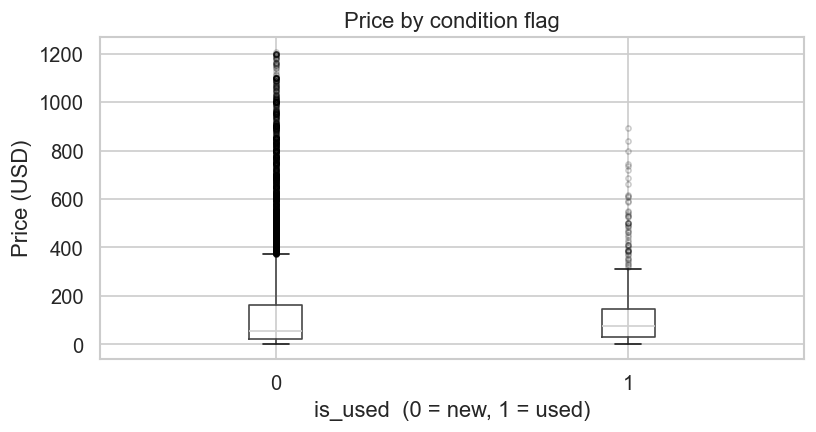

In [6]:
# does is_used explain price variance? — validates its usefulness as a feature
used_stats = (
    df.groupby('is_used')['price_usd']
    .agg(['median', 'mean', 'count'])
    .rename(index={0: 'new', 1: 'used'})
    .round(2)
)
print(used_stats)

fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='price_usd', by='is_used', ax=ax,
           flierprops=dict(marker='o', alpha=0.2, markersize=3))
ax.set_xlabel('is_used  (0 = new, 1 = used)')
ax.set_ylabel('Price (USD)')
ax.set_title('Price by condition flag')
plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering

In [7]:
# normalise manufacturer to lowercase — reduces cardinality from case variants
df['manufacturer_clean'] = df['Manufacturer'].str.strip().str.lower()

print('Unique manufacturers (raw):  ', df['Manufacturer'].nunique())
print('Unique manufacturers (clean):', df['manufacturer_clean'].nunique())

Unique manufacturers (raw):   13076
Unique manufacturers (clean): 13037


In [8]:
# parse storage capacity to a numeric value in GB
# covers formats like '64 GB', '128GB', '1 TB' (converted to GB)
def _parse_memory_gb(val: str) -> float | None:
    if not isinstance(val, str):
        return None
    match = re.search(r'([\d.]+)\s*(GB|TB)', val, re.IGNORECASE)
    if not match:
        return None
    num, unit = float(match.group(1)), match.group(2).upper()
    return num * 1024 if unit == 'TB' else num

df['internal_memory_gb'] = df['Internal Memory'].apply(_parse_memory_gb)

print('internal_memory_gb coverage:', f"{df['internal_memory_gb'].notna().mean()*100:.1f}%")
print(df['internal_memory_gb'].value_counts().head(10))

internal_memory_gb coverage: 13.3%
internal_memory_gb
64.0      644
32.0      411
128.0     298
16.0      242
256.0     132
1024.0    111
8.0       102
4.0        95
500.0      70
825.0      48
Name: count, dtype: int64


In [9]:
# parse screen size to numeric inches — e.g. '6.1 inches' → 6.1
def _parse_screen_inches(val: str) -> float | None:
    if not isinstance(val, str):
        return None
    match = re.search(r'([\d.]+)', val)
    return float(match.group(1)) if match else None

df['screen_size_in'] = df['Screen Size'].apply(_parse_screen_inches)

print('screen_size_in coverage:', f"{df['screen_size_in'].notna().mean()*100:.1f}%")
print(df['screen_size_in'].value_counts().head(8))

screen_size_in coverage: 9.9%
screen_size_in
4.7    265
5.8    194
5.5    161
6.1    145
6.5    103
6.2     75
4.0     68
6.4     64
Name: count, dtype: int64


In [10]:
# seller rating: '98%' → 98.0; some rows are raw score strings without '%'
df['seller_rating_pct'] = (
    df['Seller Rating']
    .str.replace('%', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# seller review count: volume of feedback the seller has received
df['seller_review_count'] = pd.to_numeric(df['Seller Num Of Reviews'], errors='coerce')

# log-transform the count to reduce its skew before feeding it to the model
df['log_seller_reviews'] = np.log1p(df['seller_review_count'])

print('seller_rating_pct coverage:   ', f"{df['seller_rating_pct'].notna().mean()*100:.1f}%")
print('seller_review_count coverage: ', f"{df['seller_review_count'].notna().mean()*100:.1f}%")

seller_rating_pct coverage:    62.9%
seller_review_count coverage:  70.3%


In [11]:
# title length in words — a weak but zero-cost feature
df['title_len_words'] = df['Title'].str.split().str.len()

# colour normalised to lowercase
df['color_clean'] = df['Color Category'].str.strip().str.lower()

# binary flags: presence of structured identifiers improves model confidence
df['has_model_num'] = df['Model Num'].notna().astype(int)
df['has_upc']       = df['Upc'].notna().astype(int)

print('has_model_num=1:', df['has_model_num'].sum(), f'({df["has_model_num"].mean()*100:.1f}%)')
print('has_upc=1:      ', df['has_upc'].sum(), f'({df["has_upc"].mean()*100:.1f}%)')

has_model_num=1: 1299 (7.7%)
has_upc=1:       3002 (17.8%)


---
## 5. Assemble Clean Feature Table

In [12]:
# select only the engineered columns — raw columns are not needed downstream
FEATURE_COLS = [
    # identifiers / raw text (kept for reference, not fed to model)
    'Uniq Id', 'Title',
    # target
    'price_usd', 'log_price',
    # condition
    'is_used',
    # product attributes
    'manufacturer_clean',
    'internal_memory_gb',
    'screen_size_in',
    'color_clean',
    # seller signals
    'seller_rating_pct',
    'seller_review_count',
    'log_seller_reviews',
    # title meta
    'title_len_words',
    # identifier flags
    'has_model_num',
    'has_upc',
]

df_clean = df[FEATURE_COLS].copy()
print(f'Clean table: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
df_clean.head()

Clean table: 16,901 rows × 15 columns


,Uniq Id,Title,price_usd,log_price,is_used,manufacturer_clean,internal_memory_gb,screen_size_in,color_clean,seller_rating_pct,seller_review_count,log_seller_reviews,title_len_words,has_model_num,has_upc
0,38c0bcb6ce1e5d1750b442dd9446aac9,Samsung Galaxy Note 8 6GB RAM 64GB Dual SIM (U...,369.08,5.913719,0,samsung,64.0,NaN,NaN,NaN,NaN,NaN,17.0,1,0
1,31be03c526b3b65322e73ce617fa0e57,Apple Airpods Pro with wireless charging case ...,245.00,5.505332,0,apple airpods pro with wireless charging case ...,NaN,NaN,NaN,100.0,59.0,4.094345,12.0,0,0
2,5f2eacffc44070e54ef3195d4e3889d1,"Apple iPad Pro 1st Gen. 64GB, Wi-Fi + 4G (Unlo...",431.24,6.068981,0,apple,64.0,10.5,NaN,NaN,NaN,NaN,17.0,1,0
3,63769e57a0c804cd2871d813a835ed2b,Nintendo wii console fit board and games bundle,108.73,4.698023,0,nintendo wii console fit board and games bundle,NaN,NaN,NaN,100.0,613.0,6.419995,8.0,0,0
4,dd01861b46b2d5f2d24a64c1f64c5564,Fossil smart watch,200.00,5.303305,0,fossil smart watch,NaN,NaN,NaN,100.0,2.0,1.098612,3.0,0,0


---
## 6. Missing Value Summary (Post-Engineering)

In [13]:
missing = (
    df_clean.isnull().sum()
    .to_frame('null_count')
    .assign(pct=lambda x: (x['null_count'] / len(df_clean) * 100).round(1))
    .sort_values('pct', ascending=False)
)
print(missing.to_string())

                     null_count   pct
screen_size_in            15228  90.1
internal_memory_gb        14648  86.7
color_clean               14151  83.7
seller_rating_pct          6269  37.1
seller_review_count        5020  29.7
log_seller_reviews         5021  29.7
Title                        12   0.1
title_len_words              12   0.1
Uniq Id                       0   0.0
price_usd                     0   0.0
log_price                     0   0.0
is_used                       0   0.0
manufacturer_clean            1   0.0
has_model_num                 0   0.0
has_upc                       0   0.0


In [14]:
# fields with >50% missing cannot be required model inputs
# they will be filled with a sentinel value (-1 for numerics, 'unknown' for strings)
numeric_features = [
    'internal_memory_gb', 'screen_size_in', 'seller_rating_pct',
    'seller_review_count', 'log_seller_reviews', 'title_len_words',
]
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(-1)

df_clean['manufacturer_clean'] = df_clean['manufacturer_clean'].fillna('unknown')
df_clean['color_clean']        = df_clean['color_clean'].fillna('unknown')

print('Nulls remaining after fill:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Nulls remaining after fill:
Title    12
dtype: int64


---
## 7. Feature Distributions (Post-Engineering)

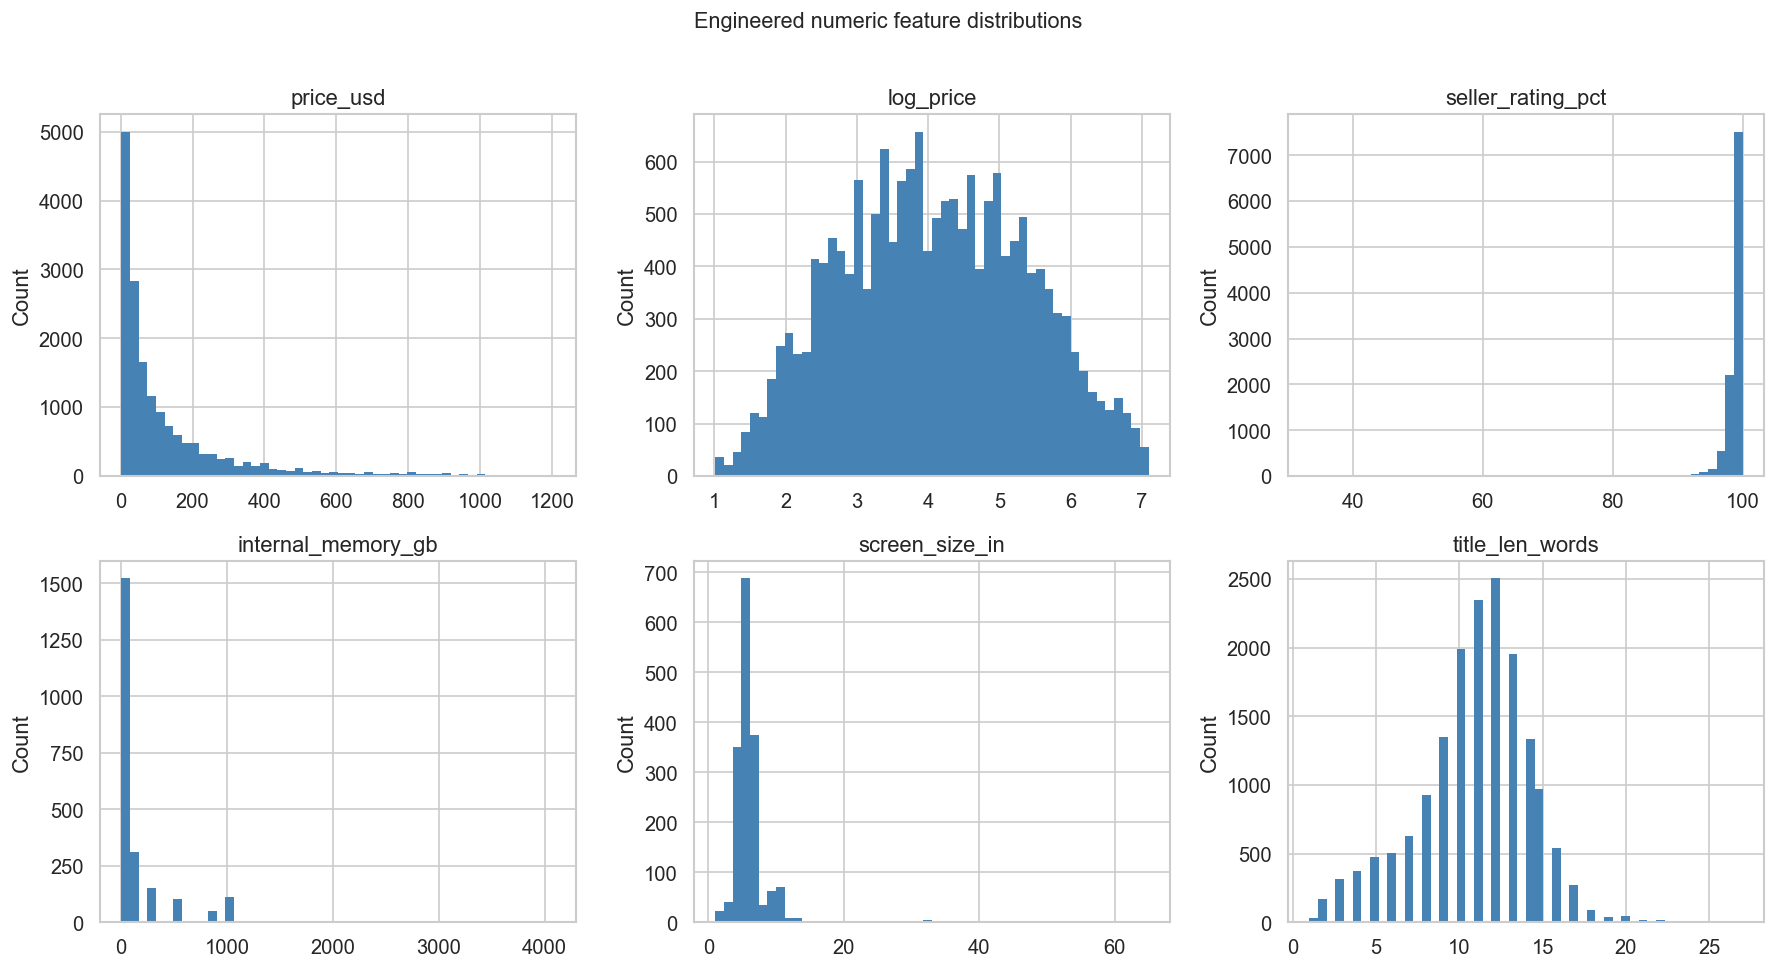

In [15]:
numeric_plot_cols = [
    'price_usd', 'log_price', 'seller_rating_pct',
    'internal_memory_gb', 'screen_size_in', 'title_len_words',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, numeric_plot_cols):
    # exclude sentinel -1 fill values from plots
    data = df_clean.loc[df_clean[col] >= 0, col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.suptitle('Engineered numeric feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

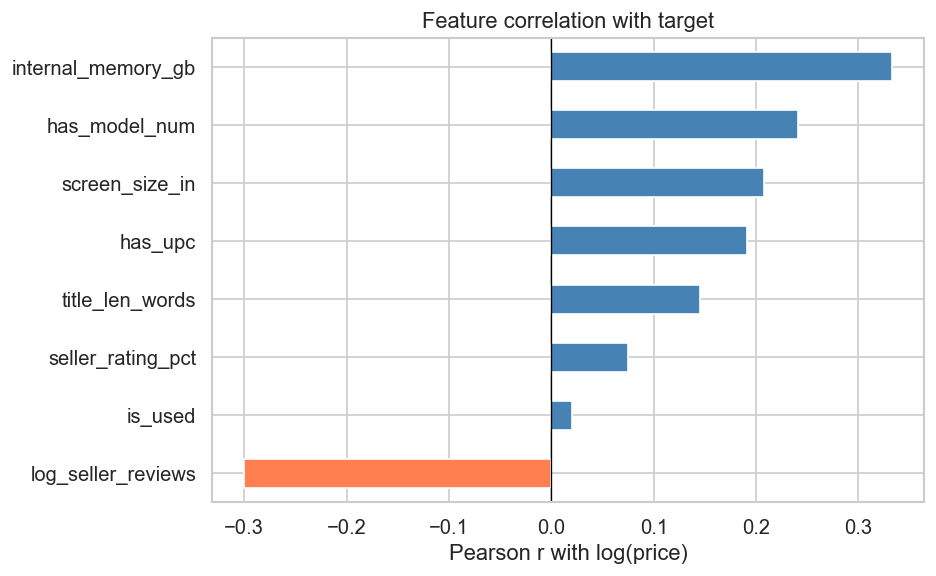

log_seller_reviews   -0.300
is_used               0.020
seller_rating_pct     0.074
title_len_words       0.145
has_upc               0.191
screen_size_in        0.208
has_model_num         0.240
internal_memory_gb    0.333


In [16]:
# correlation of every numeric feature with the target (log_price)
# is_used should show a negative correlation — used items fetch lower prices
corr_cols = [
    'log_price', 'is_used', 'internal_memory_gb', 'screen_size_in',
    'seller_rating_pct', 'log_seller_reviews', 'title_len_words',
    'has_model_num', 'has_upc',
]
corr = (
    df_clean[corr_cols]
    .replace(-1, np.nan)  # exclude sentinel fills from correlation
    .corr()['log_price']
    .drop('log_price')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['coral' if v < 0 else 'steelblue' for v in corr]
corr.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with log(price)')
ax.set_title('Feature correlation with target')
plt.tight_layout()
plt.show()

print(corr.round(3).to_string())

---
## 8. Save Processed Dataset

In [17]:
df_clean.to_parquet(OUT_PATH, index=False)

print(f'Saved → {OUT_PATH}')
print(f'Rows:    {len(df_clean):,}')
print(f'Columns: {df_clean.shape[1]}')
print(f'Size:    {OUT_PATH.stat().st_size / 1024:.1f} KB')

# quick round-trip check
check = pd.read_parquet(OUT_PATH)
assert check.shape == df_clean.shape, 'Round-trip shape mismatch!'
print('Round-trip check passed.')

Saved → ../datasets/ebay_processed.parquet
Rows:    16,901
Columns: 15
Size:    2140.0 KB


Round-trip check passed.


---
## 9. Summary

| Step | Decision |
|------|----------|
| Price parsing | Strip `$`/`,`, cast to float; drop rows with no price |
| Outlier clipping | Clip at p1/p99 to prevent extreme listings dominating training |
| Target transform | `log1p(price_usd)` — normalises right-skewed distribution |
| `is_used` | Regex over title; `brand new` / `NIB` overrides used keywords |
| Storage | Parsed to numeric GB; TB → GB conversion included |
| Screen size | Parsed to numeric inches |
| Seller rating | Strip `%`, cast float |
| Seller reviews | Cast int + `log1p` transform for skew reduction |
| Missing fill | Numeric → `-1` sentinel; string → `'unknown'` |

### Next step
Feed `ebay_processed.parquet` into `03_train_pricing_model.ipynb` to train and evaluate the XGBoost regressor.  
At inference time, `agent.py` will call `model.predict()` instead of computing a raw median.